In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.ensemble import GradientBoostingClassifier

In [8]:
# Load dataset
train_df = pd.read_csv("train.csv")
test_df = pd.read_csv("test.csv")

print("Train shape:", train_df.shape)
print("Test shape:", test_df.shape)

train_df.head()

Train shape: (8693, 14)
Test shape: (4277, 13)


,PassengerId,HomePlanet,CryoSleep,Cabin,Destination,Age,VIP,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,Name,Transported
0,0001_01,Europa,False,B/0/P,TRAPPIST-1e,39.0,False,0.0,0.0,0.0,0.0,0.0,Maham Ofracculy,False
1,0002_01,Earth,False,F/0/S,TRAPPIST-1e,24.0,False,109.0,9.0,25.0,549.0,44.0,Juanna Vines,True
2,0003_01,Europa,False,A/0/S,TRAPPIST-1e,58.0,True,43.0,3576.0,0.0,6715.0,49.0,Altark Susent,False
3,0003_02,Europa,False,A/0/S,TRAPPIST-1e,33.0,False,0.0,1283.0,371.0,3329.0,193.0,Solam Susent,False
4,0004_01,Earth,False,F/1/S,TRAPPIST-1e,16.0,False,303.0,70.0,151.0,565.0,2.0,Willy Santantines,True


In [9]:
# Feature engineering function

def clean_and_engineer(df):
    data = df.copy()

    # Split Cabin using vectorized string methods
    cabin_parts = data["Cabin"].astype(str).str.split("/", expand=True)
    data["Deck"] = cabin_parts[0].replace("nan", np.nan)
    data["CabinNum"] = pd.to_numeric(cabin_parts[1], errors="coerce")
    data["Side"] = cabin_parts[2].replace("nan", np.nan)

    # Extract Group from PassengerId (new engineered feature)
    data["Group"] = data["PassengerId"].str.split("_").str[0].astype(int)

    # Create TotalSpending feature
    spending_cols = ["RoomService", "FoodCourt", "ShoppingMall", "Spa", "VRDeck"]
    data["TotalSpending"] = data[spending_cols].sum(axis=1)

    # Drop Name and Cabin
    data.drop(["Name", "Cabin"], axis=1, inplace=True)

    return data

train_clean = clean_and_engineer(train_df)
test_clean = clean_and_engineer(test_df)

train_clean.head()


,PassengerId,HomePlanet,CryoSleep,Destination,Age,VIP,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,Transported,Deck,CabinNum,Side,Group,TotalSpending
0,0001_01,Europa,False,TRAPPIST-1e,39.0,False,0.0,0.0,0.0,0.0,0.0,False,B,0.0,P,1,0.0
1,0002_01,Earth,False,TRAPPIST-1e,24.0,False,109.0,9.0,25.0,549.0,44.0,True,F,0.0,S,2,736.0
2,0003_01,Europa,False,TRAPPIST-1e,58.0,True,43.0,3576.0,0.0,6715.0,49.0,False,A,0.0,S,3,10383.0
3,0003_02,Europa,False,TRAPPIST-1e,33.0,False,0.0,1283.0,371.0,3329.0,193.0,False,A,0.0,S,3,5176.0
4,0004_01,Earth,False,TRAPPIST-1e,16.0,False,303.0,70.0,151.0,565.0,2.0,True,F,1.0,S,4,1091.0


Missing values in training data:
PassengerId        0
HomePlanet       201
CryoSleep        217
Destination      182
Age              179
VIP              203
RoomService      181
FoodCourt        183
ShoppingMall     208
Spa              183
VRDeck           188
Transported        0
Deck             199
CabinNum         199
Side             199
Group              0
TotalSpending      0
dtype: int64


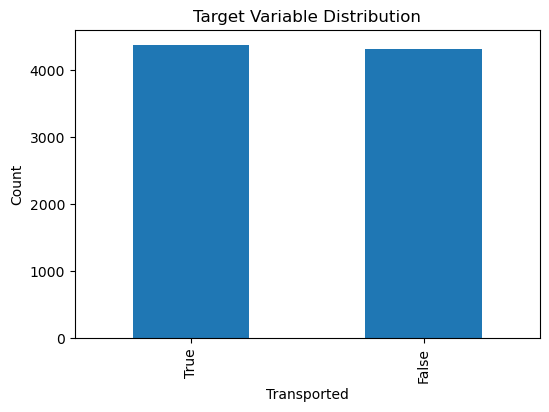

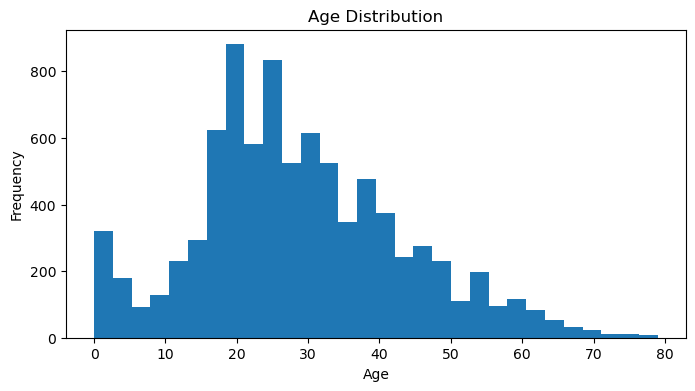

In [ ]:
# Basic EDA

print("Missing values in training data:")
print(train_clean.isnull().sum())

plt.figure(figsize=(6,4))
train_clean["Transported"].value_counts().plot(kind="bar")
plt.title("Target Variable Distribution")
plt.xlabel("Transported")
plt.ylabel("Count")
plt.show()

plt.figure(figsize=(8,4))
train_clean["Age"].plot(kind="hist", bins=30)
plt.title("Age Distribution")
plt.xlabel("Age")
plt.show()

In [11]:
X = train_clean.drop(["Transported"], axis=1)
y = train_clean["Transported"].astype(int)

X_test = test_clean.copy()
test_ids = test_clean["PassengerId"]

# Drop PassengerId from features
X = X.drop(["PassengerId"], axis=1)
X_test = X_test.drop(["PassengerId"], axis=1)

# Identify numeric and categorical columns automatically
num_cols = X.select_dtypes(include=["int64", "float64"]).columns.tolist()
cat_cols = X.select_dtypes(include=["object", "bool"]).columns.tolist()

print("Numerical columns:", num_cols)
print("Categorical columns:", cat_cols)

Numerical columns: ['Age', 'RoomService', 'FoodCourt', 'ShoppingMall', 'Spa', 'VRDeck', 'CabinNum', 'TotalSpending']
Categorical columns: ['HomePlanet', 'CryoSleep', 'Destination', 'VIP', 'Deck', 'Side']


In [12]:
numeric_pipeline = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median"))
])

categorical_pipeline = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer(transformers=[
    ("num", numeric_pipeline, num_cols),
    ("cat", categorical_pipeline, cat_cols)
])


In [13]:
gb_model = GradientBoostingClassifier(random_state=42)

model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", gb_model)
])

In [14]:
X_train, X_valid, y_train, y_valid = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Training model...")
model.fit(X_train, y_train)

valid_preds = model.predict(X_valid)
acc = accuracy_score(y_valid, valid_preds)

print("Validation Accuracy:", acc)

Training model...
Validation Accuracy: 0.7993099482461185


In [15]:
print("Training full model...")
model.fit(X, y)

print("Predicting on test set...")
test_preds = model.predict(X_test)

submission = pd.DataFrame({
    "PassengerId": test_ids,
    "Transported": test_preds.astype(bool)
})

submission.to_csv("submission.csv", index=False)
print("submission.csv saved successfully!")
submission.head()

Training full model...
Predicting on test set...
submission.csv saved successfully!


,PassengerId,Transported
0,0013_01,True
1,0018_01,False
2,0019_01,True
3,0021_01,True
4,0023_01,True
